<a href="https://colab.research.google.com/github/Asripramudiya/forecesting/blob/main/Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 20.7 MB/s eta 0:00:00


# Import Library

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from prophet.plot import plot_plotly
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg,ARResults
nlag = 40
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Read Data

In [3]:
df = pd.read_excel("https://raw.githubusercontent.com/Asripramudiya/forecesting/main/forecasting.xlsx")
df.head()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
0,19272,2013-01-11,AUTOMOTIVE,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
1,953040,2014-06-20,AUTOMOTIVE,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.36,12440.0,8500.0,112.0,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
2,1452,2013-01-01,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
3,26400,2013-01-15,AUTOMOTIVE,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
4,5016,2013-01-03,AUTOMOTIVE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# mengurutkan tanggal berdasar category
df = df.sort_values(['category', 'date'])

In [5]:
df.head()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
2,1452,2013-01-01,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
110,3234,2013-01-02,AUTOMOTIVE,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
4,5016,2013-01-03,AUTOMOTIVE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
310,6798,2013-01-04,AUTOMOTIVE,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
5,8580,2013-01-05,AUTOMOTIVE,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN


# Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55572 entries, 2 to 55216
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         55572 non-null  int64         
 1   date                       55572 non-null  datetime64[ns]
 2   category                   55572 non-null  object        
 3   qty                        55572 non-null  float64       
 4   year                       0 non-null      float64       
 5   month                      0 non-null      float64       
 6   day_of_month               0 non-null      float64       
 7   day_of_week                0 non-null      float64       
 8   week_of_year               0 non-null      float64       
 9   quarter                    0 non-null      float64       
 10  is_weekend                 0 non-null      float64       
 11  day_name                   0 non-null      float64       
 12  is_payday

In [7]:
df.describe()

,id,date,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
count,5.557200e+04,55572,55572.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55572.000000,55572.000000,55572.000000,55572.000000,55572.00000,55572.000000,0.0,55572.000000,55572.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,1.501021e+06,2015-04-24 08:27:04.703087872,477.613744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087292,5.483688,12916.139549,7292.695962,114.92696,31363.636364,NaN,0.293943,0.032660,NaN,NaN,NaN,NaN,NaN,NaN
min,1.452000e+03,2013-01-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.020000,12039.000000,6500.000000,108.50000,12000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.512365e+05,2014-02-26 18:00:00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.350000,12339.000000,6550.000000,111.40000,25000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.501021e+06,2015-04-24 12:00:00,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.610000,13229.000000,7400.000000,114.40000,25000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.250806e+06,2016-06-19 06:00:00,281.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,8.360000,13366.000000,7650.000000,118.00000,25000.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,3.000590e+06,2017-08-15 00:00:00,35279.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,8.380000,13629.000000,8500.000000,122.60000,95000.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,8.662894e+05,NaN,1538.413443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282265,2.524774,528.398062,768.210449,3.95312,17915.480829,NaN,0.455570,0.177748,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,55572
month,55572
day_of_month,55572
day_of_week,55572
week_of_year,55572
quarter,55572


In [10]:
df.groupby('category')['category_group'].unique()

,category_group
category,
AUTOMOTIVE,[Automotive]
BABY CARE,[Baby & Kids]
BEAUTY,[Beauty & Health]
BEVERAGES,[Food & Beverage]
BOOKS,[Lifestyle]
BREAD/BAKERY,[Food & Beverage]
CELEBRATION,[Lifestyle]
CLEANING,[Household]
DAIRY,[Food & Beverage]


# Feature Engineering

In [11]:
# Kolom Date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] =df['date'].dt.isocalendar().week
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = df['date'].dt.dayofweek.isin([5,6]).astype(int)
df['day_name'] = df['date'].dt.day_name()

In [12]:
# Mengisi revenue
df['revenue'] = df['qty']*df['avg_price']

In [13]:
# Periode gajian
df['is_payday_period'] = (df['date'].dt.day >= 25) | (df['date'].dt.day <=5).astype(int)

In [14]:
# Mengisi tanggal kembar
df['event_harbolnas'] = (
    ((df['month'] == 1) & (df['date'].dt.day == 1)) |
    ((df['month'] == 2) & (df['date'].dt.day == 2)) |
    ((df['month'] == 3) & (df['date'].dt.day == 3)) |
    ((df['month'] == 4) & (df['date'].dt.day == 4)) |
    ((df['month'] == 5) & (df['date'].dt.day == 5)) |
    ((df['month'] == 6) & (df['date'].dt.day == 6)) |
    ((df['month'] == 7) & (df['date'].dt.day == 7)) |
    ((df['month'] == 8) & (df['date'].dt.day == 8)) |
    ((df['month'] == 9) & (df['date'].dt.day == 9)) |
    ((df['month'] == 10) & (df['date'].dt.day == 10)) |
    ((df['month'] == 11) & (df['date'].dt.day == 11)) |
    ((df['month'] == 12) & (df['date'].dt.day == 12))
).astype(int)

In [15]:
# Mengisi lag qty (nilai qty penjualan sebelumnya)
df['lag_1_qty'] = (df.groupby('category')['qty'].shift(1))
df['lag_7_qty'] = (df.groupby('category')['qty'].shift(7))
df['rolling_avg_7_qty'] = (df.groupby('category')['qty'].transform(lambda x: x.shift(1).rolling(7).mean().round(2)))

In [16]:
# Mengisi lag revenue (nilai revenue penjualan sebelumnya) dihitung per categori
df['lag_1_revenue'] = (df.groupby('category')['revenue'].shift(1))
df['lag_7_revenue'] = (df.groupby('category')['revenue'].shift(7))
df['rolling_avg_7_revenue'] = (df.groupby('category')['revenue'].transform(lambda x: x.shift(1).rolling(7).mean().round(2)))

In [17]:
df.tail()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
55212,2993462,2017-08-11,SEAFOOD,9.0,2017,8,11,4,32,3,0,Friday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,225000.0,0,0,Food & Beverage,7.0,13.0,11.14,175000.0,325000.0,278571.43
55213,2995244,2017-08-12,SEAFOOD,8.0,2017,8,12,5,32,3,1,Saturday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,200000.0,1,0,Food & Beverage,9.0,8.0,10.57,225000.0,200000.0,264285.71
55214,2997026,2017-08-13,SEAFOOD,13.0,2017,8,13,6,32,3,1,Sunday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,325000.0,1,0,Food & Beverage,8.0,16.0,10.57,200000.0,400000.0,264285.71
55215,2998808,2017-08-14,SEAFOOD,12.0,2017,8,14,0,33,3,0,Monday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,300000.0,0,0,Food & Beverage,13.0,9.0,10.14,325000.0,225000.0,253571.43
55216,3000590,2017-08-15,SEAFOOD,10.0,2017,8,15,1,33,3,0,Tuesday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,250000.0,0,0,Food & Beverage,12.0,16.0,10.57,300000.0,400000.0,264285.71


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55572 entries, 2 to 55216
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         55572 non-null  int64         
 1   date                       55572 non-null  datetime64[ns]
 2   category                   55572 non-null  object        
 3   qty                        55572 non-null  float64       
 4   year                       55572 non-null  int32         
 5   month                      55572 non-null  int32         
 6   day_of_month               55572 non-null  int32         
 7   day_of_week                55572 non-null  int32         
 8   week_of_year               55572 non-null  UInt32        
 9   quarter                    55572 non-null  int32         
 10  is_weekend                 55572 non-null  int64         
 11  day_name                   55572 non-null  object        
 12  is_payday

# Missing Value

In [19]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,0
month,0
day_of_month,0
day_of_week,0
week_of_year,0
quarter,0


In [20]:
# isi nilai kosong dengan 0
df = df.fillna(0)

In [21]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,0
month,0
day_of_month,0
day_of_week,0
week_of_year,0
quarter,0


# Ubah Tipe Data

In [22]:
# Ubah tipe data
df['qty'] = df['qty'].astype(int)
df['lag_1_qty'] = df['lag_1_qty'].astype(int)
df['lag_7_qty'] = df['lag_7_qty'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55572 entries, 2 to 55216
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         55572 non-null  int64         
 1   date                       55572 non-null  datetime64[ns]
 2   category                   55572 non-null  object        
 3   qty                        55572 non-null  int64         
 4   year                       55572 non-null  int32         
 5   month                      55572 non-null  int32         
 6   day_of_month               55572 non-null  int32         
 7   day_of_week                55572 non-null  int32         
 8   week_of_year               55572 non-null  UInt32        
 9   quarter                    55572 non-null  int32         
 10  is_weekend                 55572 non-null  int64         
 11  day_name                   55572 non-null  object        
 12  is_payday

In [24]:
df

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
2,1452,2013-01-01,AUTOMOTIVE,0,2013,1,1,1,1,1,0,Tuesday,True,1,0,8.38,12039.0,6500.0,108.5,25000.0,0.0,1,0,Automotive,0,0,0.00,0.0,0.0,0.00
110,3234,2013-01-02,AUTOMOTIVE,7,2013,1,2,2,1,1,0,Wednesday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,175000.0,0,0,Automotive,0,0,0.00,0.0,0.0,0.00
4,5016,2013-01-03,AUTOMOTIVE,5,2013,1,3,3,1,1,0,Thursday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,125000.0,0,0,Automotive,7,0,0.00,175000.0,0.0,0.00
310,6798,2013-01-04,AUTOMOTIVE,7,2013,1,4,4,1,1,0,Friday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,175000.0,0,0,Automotive,5,0,0.00,125000.0,0.0,0.00
5,8580,2013-01-05,AUTOMOTIVE,6,2013,1,5,5,1,1,1,Saturday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,150000.0,1,0,Automotive,7,0,0.00,175000.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55212,2993462,2017-08-11,SEAFOOD,9,2017,8,11,4,32,3,0,Friday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,225000.0,0,0,Food & Beverage,7,13,11.14,175000.0,325000.0,278571.43
55213,2995244,2017-08-12,SEAFOOD,8,2017,8,12,5,32,3,1,Saturday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,200000.0,1,0,Food & Beverage,9,8,10.57,225000.0,200000.0,264285.71
55214,2997026,2017-08-13,SEAFOOD,13,2017,8,13,6,32,3,1,Sunday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,325000.0,1,0,Food & Beverage,8,16,10.57,200000.0,400000.0,264285.71
55215,2998808,2017-08-14,SEAFOOD,12,2017,8,14,0,33,3,0,Monday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,300000.0,0,0,Food & Beverage,13,9,10.14,325000.0,225000.0,253571.43


# EDA

In [25]:
# heatmap korelasi
cols = [
    'qty',
    'revenue',
    'avg_price',
    'fuel_price',
    'usd_idr_rate',
    'inflation_rate',
    'consumer_confidence_index',
    'usd_idr_rate',
    'fuel_price',
    'is_payday_period',
    'event_harbolnas',
    'lag_1_qty',
    'lag_7_qty',
    'rolling_avg_7_qty'
]

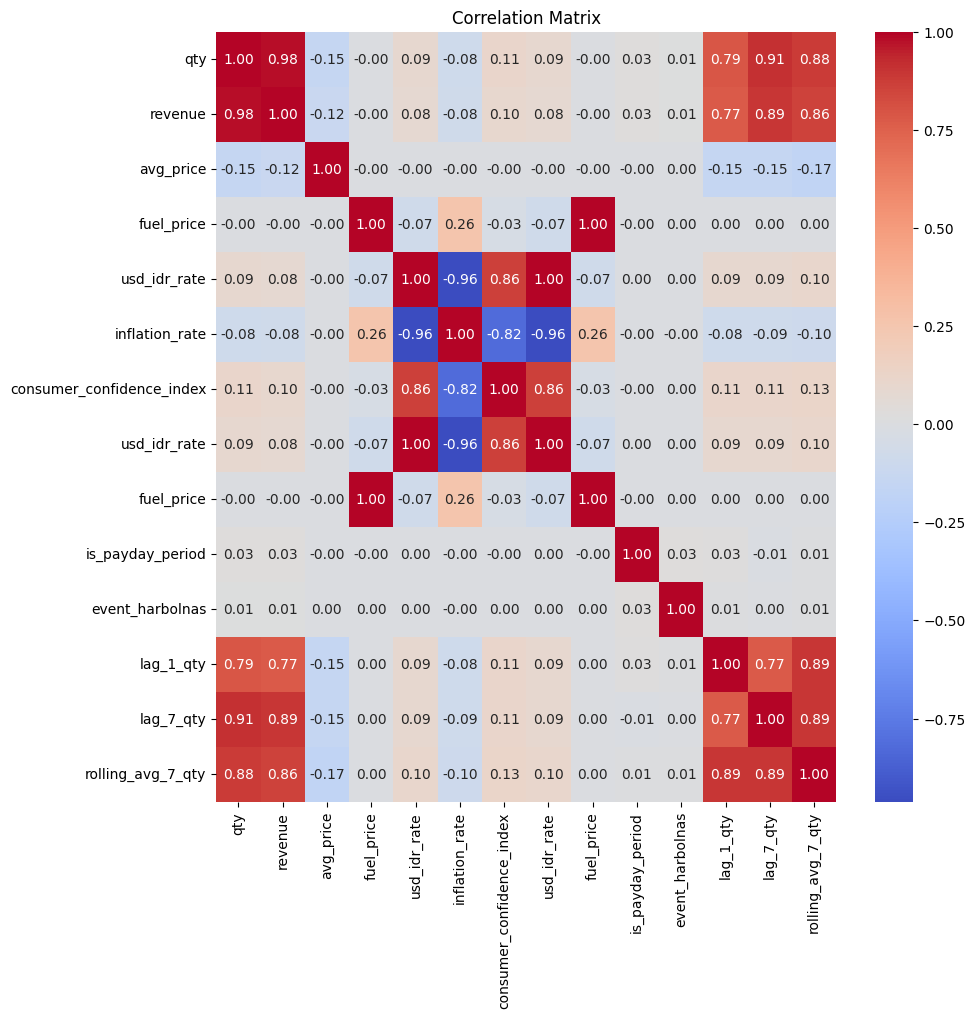

In [26]:
corr = df[cols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

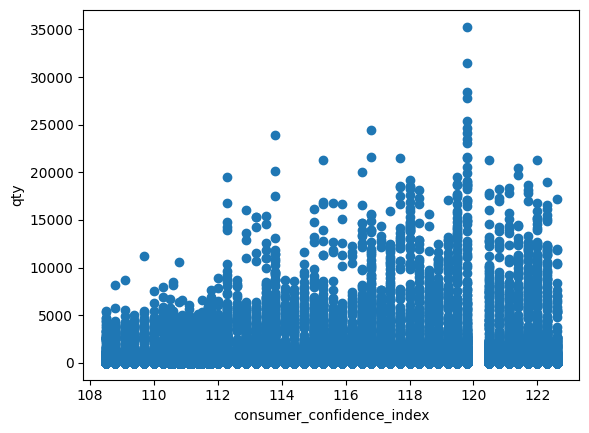

In [27]:
# qty vs consumer confidence index
plt.scatter(df['consumer_confidence_index'], df['qty'])
plt.xlabel('consumer_confidence_index')
plt.ylabel('qty')
plt.show()

In [28]:
df[['qty','consumer_confidence_index']].corr()

,qty,consumer_confidence_index
qty,1.000000,0.110984
consumer_confidence_index,0.110984,1.000000


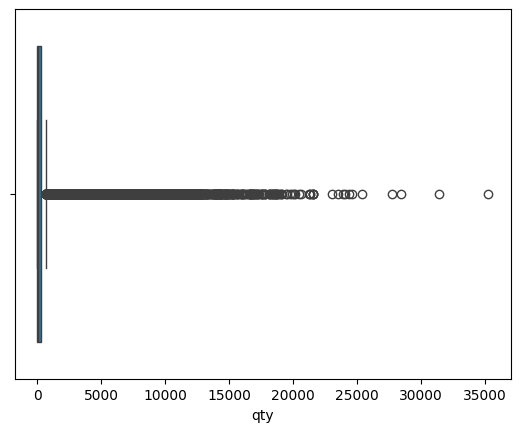

In [29]:
sns.boxplot(x=df['qty'])
plt.show()

In [30]:
df.nlargest(10, 'qty')[['date','is_payday_period','category','qty','revenue']]

,date,is_payday_period,category,qty,revenue
21541,2016-12-23,False,GROCERY I,35279,881975000.0
21542,2016-12-24,False,GROCERY I,31439,785975000.0
21536,2016-12-18,False,GROCERY I,28419,710475000.0
21548,2016-12-31,True,GROCERY I,27768,694200000.0
21547,2016-12-30,True,GROCERY I,25377,634425000.0
21540,2016-12-22,False,GROCERY I,24605,615125000.0
51272,2015-12-30,True,PRODUCE,24391,609775000.0
21522,2016-12-04,True,GROCERY I,24093,602325000.0
50909,2014-12-31,True,PRODUCE,23937,598425000.0
21539,2016-12-21,False,GROCERY I,23510,587750000.0


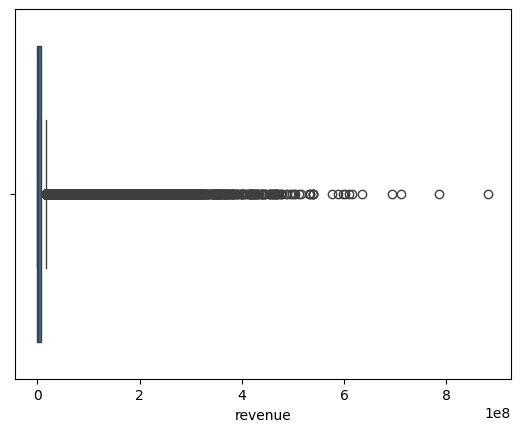

In [31]:
sns.boxplot(x=df['revenue'])
plt.show()

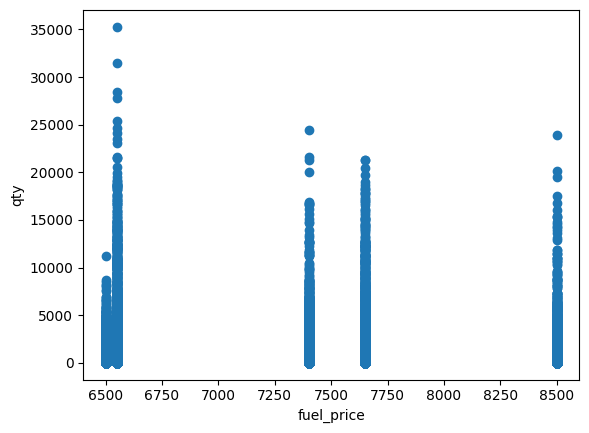

In [32]:
# Pengaruh terhadap fuel price
plt.scatter(df['fuel_price'], df['qty'])
plt.xlabel('fuel_price')
plt.ylabel('qty')
plt.show()

fuel price tidak memiliki pengaruh terhadap permintaan pelanggan

In [33]:
df[['qty','fuel_price']].corr()

,qty,fuel_price
qty,1.000000,-0.000197
fuel_price,-0.000197,1.000000


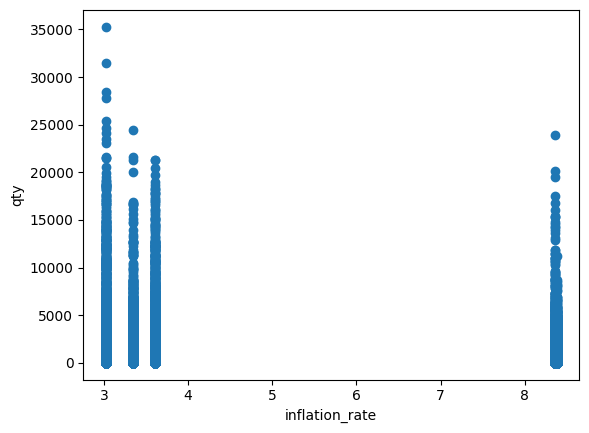

In [34]:
# Pengaruh inflasi
plt.scatter(df['inflation_rate'], df['qty'])
plt.xlabel('inflation_rate')
plt.ylabel('qty')
plt.show()

Inflation rate tidak memiliki pengaruh terhadap permintaan pelanggan

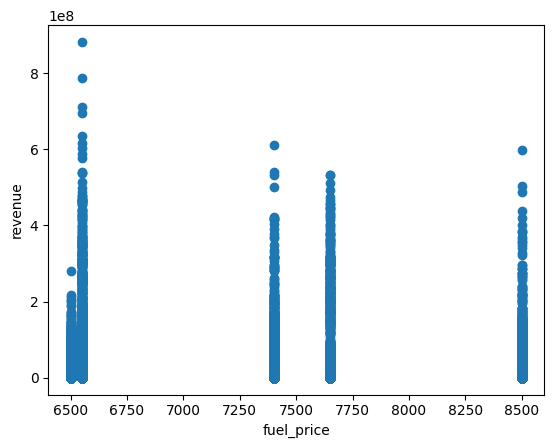

In [35]:
# Pengaruh fuel price, revenue
plt.scatter(df['fuel_price'], df['revenue'])
plt.xlabel('fuel_price')
plt.ylabel('revenue')
plt.show()

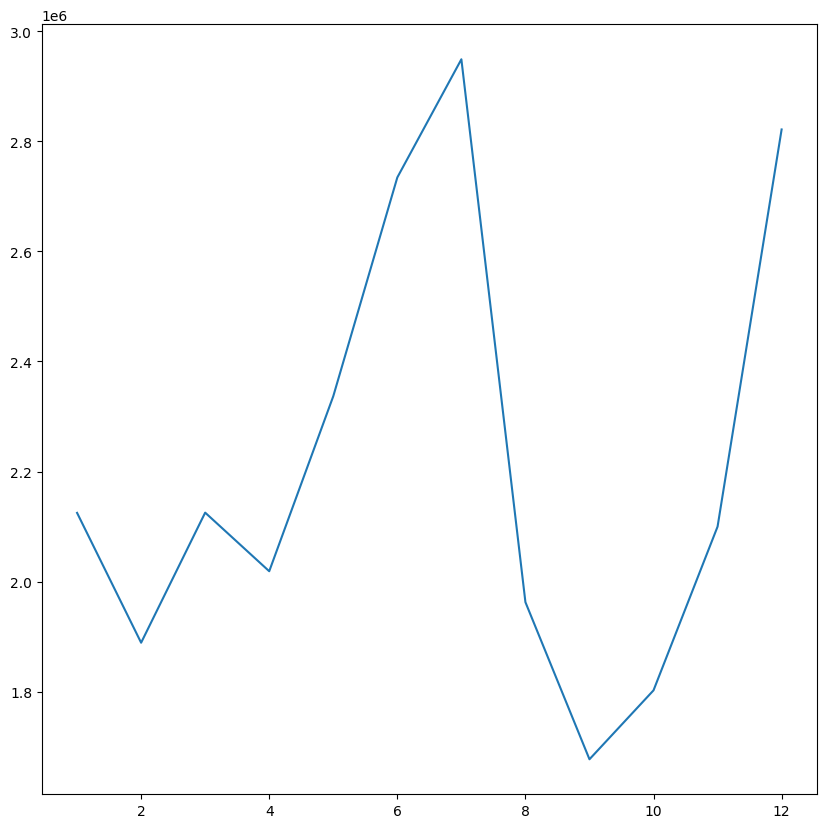

In [36]:
monthly = df.groupby('month')['qty'].sum()
plt.figure(figsize=(10,10))
plt.plot(monthly)
plt.show()

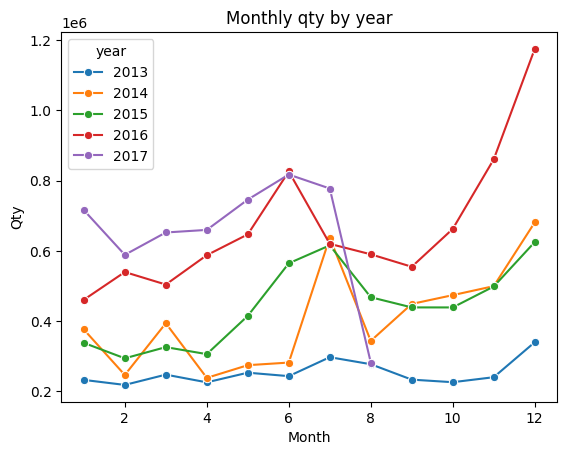

In [37]:
monthly_year = df.groupby(['year', 'month'])['qty'].sum().reset_index()
sns.lineplot(data=monthly_year, x='month', y='qty', hue='year', marker='o', palette='tab10')
plt.xlabel('Month')
plt.ylabel('Qty')
plt.title('Monthly qty by year')
plt.show()

In [38]:
df['qty'].describe()

,qty
count,55572.000000
mean,477.613744
std,1538.413443
min,0.000000
25%,1.000000
50%,22.000000
75%,281.000000
max,35279.000000


Sebagian besar hari memiliki penjualan rendah namun terdapat beberapa hari dengan penjualan sanggat tinggi yang menyebabkan rata-rata meningkat

In [39]:
# Coefficient of Variation
cv = df['qty'].std()/df['qty'].mean()
print(cv)

3.2210409799380364


Permintaan sangat fluktuatif karena nilai 3.2

In [40]:
df.nlargest(10, 'revenue')[['date','is_payday_period','category','qty','revenue']]

,date,is_payday_period,category,qty,revenue
21541,2016-12-23,False,GROCERY I,35279,881975000.0
21542,2016-12-24,False,GROCERY I,31439,785975000.0
21536,2016-12-18,False,GROCERY I,28419,710475000.0
21548,2016-12-31,True,GROCERY I,27768,694200000.0
21547,2016-12-30,True,GROCERY I,25377,634425000.0
21540,2016-12-22,False,GROCERY I,24605,615125000.0
51272,2015-12-30,True,PRODUCE,24391,609775000.0
21522,2016-12-04,True,GROCERY I,24093,602325000.0
50909,2014-12-31,True,PRODUCE,23937,598425000.0
21539,2016-12-21,False,GROCERY I,23510,587750000.0


In [41]:
df.head()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
2,1452,2013-01-01,AUTOMOTIVE,0,2013,1,1,1,1,1,0,Tuesday,True,1,0,8.38,12039.0,6500.0,108.5,25000.0,0.0,1,0,Automotive,0,0,0.0,0.0,0.0,0.0
110,3234,2013-01-02,AUTOMOTIVE,7,2013,1,2,2,1,1,0,Wednesday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,175000.0,0,0,Automotive,0,0,0.0,0.0,0.0,0.0
4,5016,2013-01-03,AUTOMOTIVE,5,2013,1,3,3,1,1,0,Thursday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,125000.0,0,0,Automotive,7,0,0.0,175000.0,0.0,0.0
310,6798,2013-01-04,AUTOMOTIVE,7,2013,1,4,4,1,1,0,Friday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,175000.0,0,0,Automotive,5,0,0.0,125000.0,0.0,0.0
5,8580,2013-01-05,AUTOMOTIVE,6,2013,1,5,5,1,1,1,Saturday,True,0,0,8.38,12039.0,6500.0,108.5,25000.0,150000.0,1,0,Automotive,7,0,0.0,175000.0,0.0,0.0


<Axes: xlabel='year'>

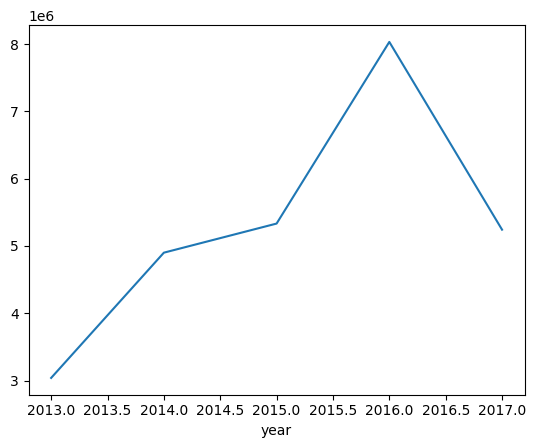

In [42]:
# Tren penjualan per tahun
yearly_qty = df.groupby('year')['qty'].sum()
yearly_qty.plot()

<Axes: xlabel='month'>

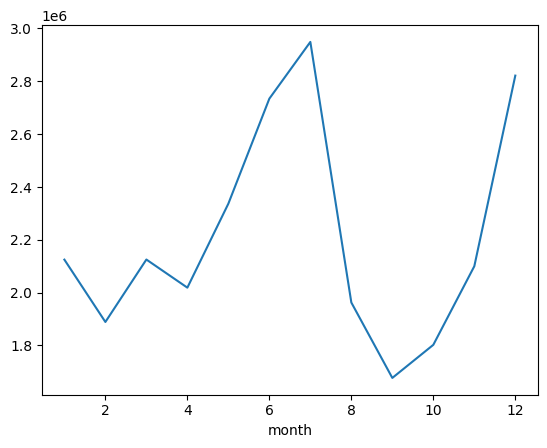

In [43]:
# Tren Penjualan per bulan
monthly_qty = df.groupby('month')['qty'].sum()
monthly_qty.plot()

<Axes: xlabel='day_of_month'>

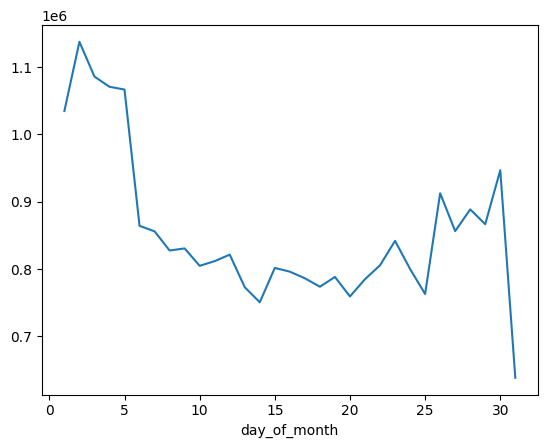

In [44]:
# Tren penjualan per hari
daily_qty = df.groupby('day_of_month')['qty'].sum()
daily_qty.plot()

In [45]:
# Pengaruh event ramadan
df.groupby('event_ramadan')[['qty','revenue']].mean()

,qty,revenue
event_ramadan,,
0,459.629345,1.047007e+07
1,665.654710,1.514431e+07


In [46]:
# Pengaruh event eid
df.groupby('event_eid')[['qty','revenue']].mean()

,qty,revenue
event_eid,,
0,472.735514,1.076463e+07
1,622.098072,1.423860e+07


In [47]:
# Pengaruh payday
df.groupby('is_payday_period')[['qty','revenue']].mean()

,qty,revenue
is_payday_period,,
False,438.732299,9.993007e+06
True,542.828251,1.236262e+07


In [48]:
# Pengaruh Harbolnas
df.groupby('event_harbolnas')[['qty','revenue']].mean()

,qty,revenue
event_harbolnas,,
0,473.683884,1.078861e+07
1,591.860390,1.347959e+07


In [49]:
# save to excel
df.to_excel("forecasting_clean.xlsx", index=False)

In [50]:
df_ml = df.copy()

# ML2

In [51]:
monthly_qty = (df_ml.groupby(pd.Grouper(key='date', freq='MS'))['qty'].sum())

In [52]:
monthly_qty = monthly_qty[monthly_qty.index < '2017-08-01']

In [53]:
print(monthly_qty.tail())

date
2017-03-01    652548
2017-04-01    659857
2017-05-01    746072
2017-06-01    817435
2017-07-01    777693
Freq: MS, Name: qty, dtype: int64


In [54]:
monthly_revenue = (df_ml.groupby(pd.Grouper(key='date', freq='MS'))['revenue'].sum())

In [55]:
monthly_revenue = monthly_revenue[monthly_revenue.index < '2017-08-01']

In [56]:
print(monthly_revenue.tail())

date
2017-03-01    1.447170e+10
2017-04-01    1.502838e+10
2017-05-01    1.683968e+10
2017-06-01    1.846734e+10
2017-07-01    1.750948e+10
Freq: MS, Name: revenue, dtype: float64


# Train Test Split

In [57]:
train_size = int(len(monthly_qty) * 0.8)
train_qty = monthly_qty[:train_size]
test_qty = monthly_qty[train_size:]

In [58]:
test_qty

,qty
date,
2016-09-01,554941
2016-10-01,662625
2016-11-01,860727
2016-12-01,1174931
2017-01-01,716187
2017-02-01,588903
2017-03-01,652548
2017-04-01,659857
2017-05-01,746072


In [59]:
train_size_revenue = int(len(monthly_revenue) * 0.8)
train_revenue = monthly_revenue[:train_size_revenue]
test_revenue = monthly_revenue[train_size_revenue:]

In [60]:
test_revenue

,revenue
date,
2016-09-01,1.241372e+10
2016-10-01,1.508828e+10
2016-11-01,1.899308e+10
2016-12-01,2.672256e+10
2017-01-01,1.586741e+10
2017-02-01,1.345306e+10
2017-03-01,1.447170e+10
2017-04-01,1.502838e+10
2017-05-01,1.683968e+10


In [61]:
print(train_revenue.index.min())
print(train_revenue.index.max())

print(test_revenue.index.min())
print(test_revenue.index.max())

2013-01-01 00:00:00
2016-08-01 00:00:00
2016-09-01 00:00:00
2017-07-01 00:00:00


# ARIMA

## Monthly Sales

In [62]:
auto_model_qty = auto_arima(train_qty, seasonal=False, trace=True)
print(auto_model_qty.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1134.442, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1129.661, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1124.941, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1132.647, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1127.473, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1132.077, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1125.388, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.558 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   44
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -559.471
Date:                Wed, 17 Jun 2026   AIC                

In [63]:
arima_model_qty = ARIMA(train_qty, order=(0,1,1)) # dari nilai best model
arima_fit_qty = arima_model_qty.fit()

In [64]:
arima_pred_qty = arima_fit_qty.forecast(len(test_qty))

In [65]:
arima_future_qty = arima_fit_qty.forecast(steps=12)

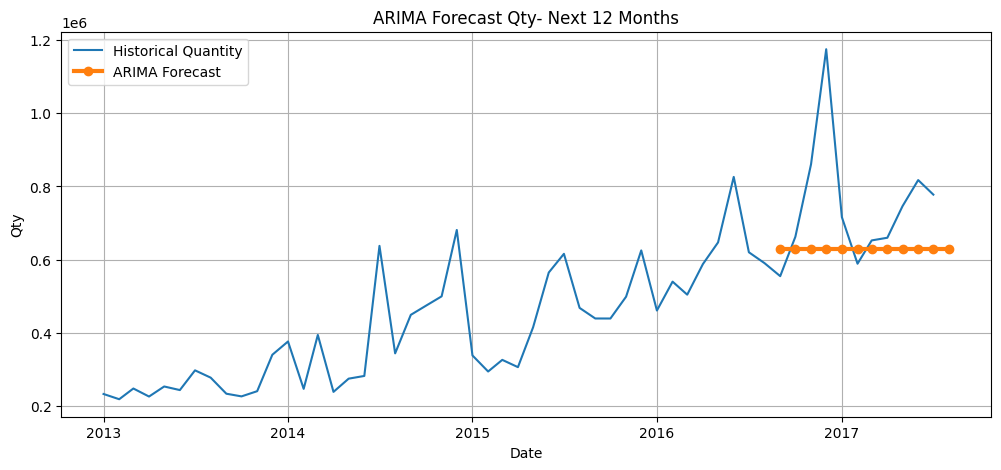

In [128]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_qty.index,
    monthly_qty.values,
    label='Historical Quantity')
plt.plot(
    arima_future_qty.index,
    arima_future_qty.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast')
plt.title('ARIMA Forecast Qty- Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

## Revenue Monthly

In [67]:
auto_model_revenue = auto_arima(train_revenue, seasonal=False, trace=True)
print(auto_model_revenue.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1996.623, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1992.498, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1987.151, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1994.801, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1990.164, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1995.136, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1987.761, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.488 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   44
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -990.575
Date:                Wed, 17 Jun 2026   AIC                

In [68]:
arima_model_revenue = ARIMA(train_revenue, order=(0,1,1)) # dari nilai best model
arima_fit_revenue = arima_model_revenue.fit()

In [69]:
arima_pred_revenue = arima_fit_revenue.forecast(len(test_revenue))

In [70]:
arima_future_revenue = arima_fit_revenue.forecast(steps=12)

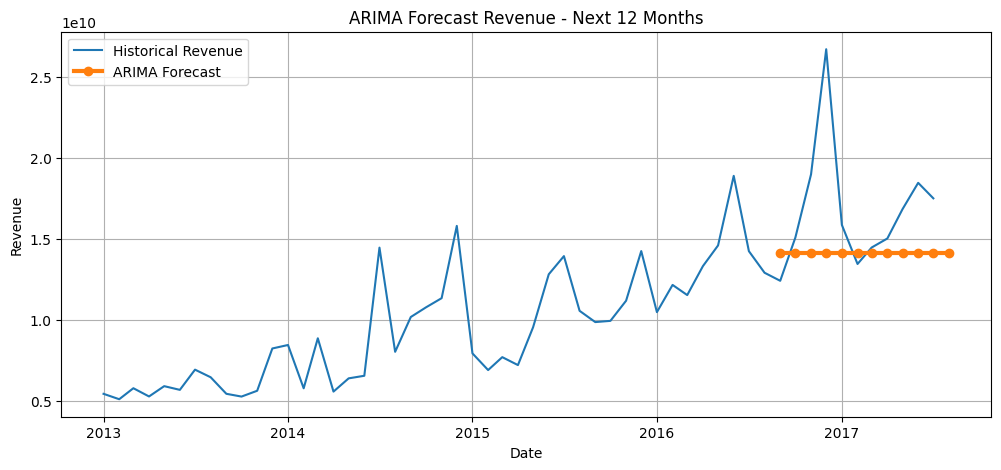

In [129]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    arima_future_revenue.index,
    arima_future_revenue.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast')
plt.title('ARIMA Forecast Revenue - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

# SARIMA

## Monthly Sales

In [72]:
auto_arima(train_qty, seasonal=True, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1134.442, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1126.752, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1122.057, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1132.647, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1124.941, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1122.065, Time=0.14 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1123.271, Time=0.14 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1125.666, Time=0.06 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1123.610, Time=0.38 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1128.640, Time=0.12 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=1124.075, Time=0.23 sec
 ARIMA(0,1,2)(0,0,1)[12] intercept   : AIC=1126.179, Time=0.80 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1123.431, Time=0.26 sec
 ARIMA(1,1,2)(0,0,1)[12]

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True, with_intercept=False)

In [73]:
sarima_model_qty = SARIMAX(train_qty, order=(0,1,1), seasonal_order=(0,0,1,12))
sarima_fit_qty = sarima_model_qty.fit()

In [74]:
sarima_pred_qty = sarima_fit_qty.forecast(len(test_qty))

In [75]:
sarima_future_qty = sarima_fit_qty.forecast(steps=12)

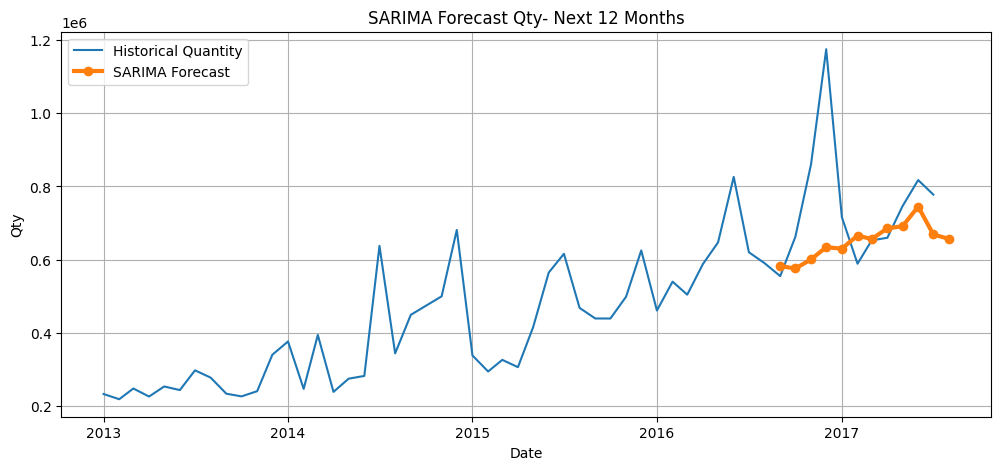

In [127]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_qty.index,
    monthly_qty.values,
    label='Historical Quantity')
plt.plot(
    sarima_future_qty.index,
    sarima_future_qty.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast')
plt.title('SARIMA Forecast Qty- Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

## Revenue Monthly

In [77]:
auto_arima(train_revenue, seasonal=True, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1988.898, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1996.623, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1988.956, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1983.937, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1994.801, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1987.151, Time=0.03 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1984.272, Time=0.13 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1985.361, Time=0.15 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1987.683, Time=0.07 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1985.781, Time=0.36 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1989.956, Time=0.05 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=1986.026, Time=0.09 sec
 ARIMA(0,1,2)(0,0,1)[12] intercept   : AIC=1988.048, Time=0.09 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1985.555, Time=0.06 sec
 ARIMA(1,1,2)(0,0,1

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True, with_intercept=False)

In [78]:
sarima_model_revenue = SARIMAX(train_revenue, order=(0,1,1), seasonal_order=(0,0,1,12))
sarima_fit_revenue = sarima_model_revenue.fit()

In [79]:
sarima_pred_revenue = sarima_fit_revenue.forecast(len(test_revenue))

In [80]:
sarima_future_revenue = sarima_fit_revenue.forecast(steps=12)

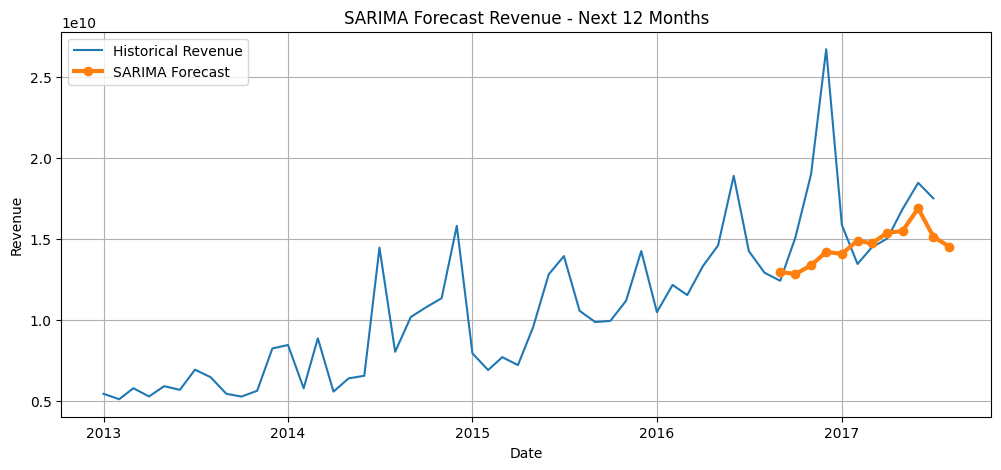

In [126]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    sarima_future_revenue.index,
    sarima_future_revenue.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast')
plt.title('SARIMA Forecast Revenue - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

# Holt Winter

## Monthly Sales

In [82]:
hw_model_qty = ExponentialSmoothing(train_qty, seasonal_periods=12, trend='add', seasonal='add')
hw_fit_qty = hw_model_qty.fit()
hw_pred_qty = hw_fit_qty.forecast(len(test_qty))
hw_future_qty = hw_fit_qty.forecast(12)

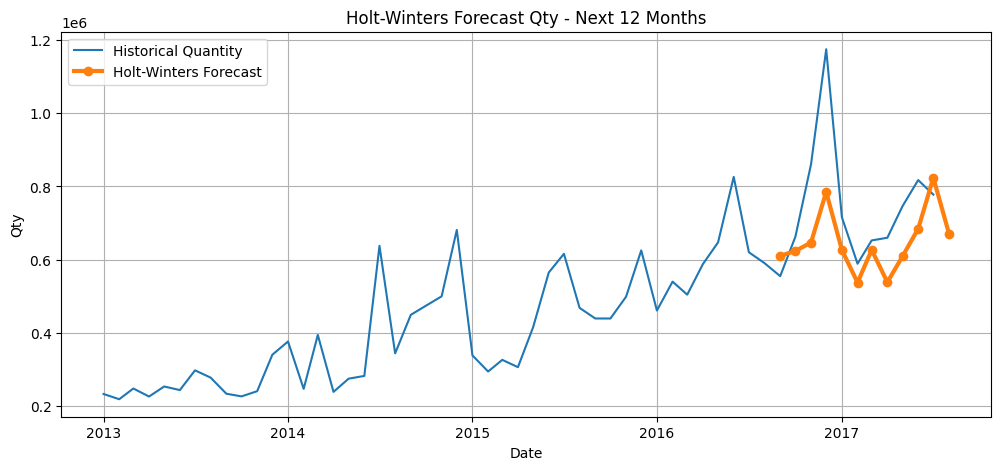

In [125]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_qty.index,
    monthly_qty.values,
    label='Historical Quantity')
plt.plot(
    hw_future_qty.index,
    hw_future_qty.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast Qty - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

## Revenue Monthly

In [116]:
hw_model_revenue = ExponentialSmoothing(train_revenue, seasonal_periods=12, trend='add', seasonal='add')
hw_fit_revenue = hw_model_revenue.fit()
hw_pred_revenue = hw_fit_revenue.forecast(len(test_revenue))
hw_future_revenue = hw_fit_revenue.forecast(12)

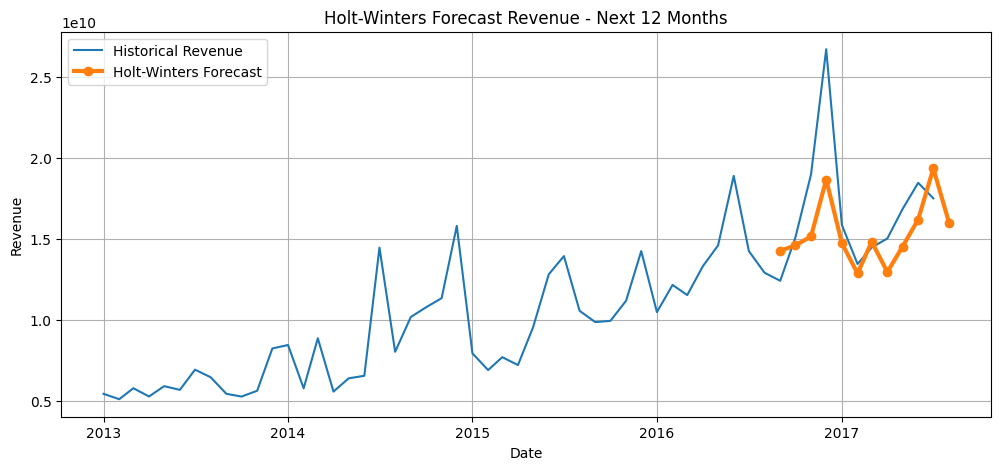

In [124]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    hw_future_revenue.index,
    hw_future_revenue.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast Revenue - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

In [123]:
future_dates = pd.date_range(
    start=test_revenue.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)
forecast_revenue_table = pd.DataFrame({
    'Date': future_dates.strftime('%b-%Y'),
    'Forecast_Revenue': hw_future_revenue.values
})

forecast_revenue_table['Forecast_Revenue'] = (
    forecast_revenue_table['Forecast_Revenue']
    .map('{:,.0f}'.format)
)

forecast_revenue_table

,Date,Forecast_Revenue
0,Aug-2017,"14,267,720,786"
1,Sep-2017,"14,602,149,221"
2,Oct-2017,"15,152,531,240"
3,Nov-2017,"18,669,270,280"
4,Dec-2017,"14,746,832,528"
5,Jan-2018,"12,865,250,713"
6,Feb-2018,"14,834,180,294"
7,Mar-2018,"12,955,492,167"
8,Apr-2018,"14,523,566,790"
9,May-2018,"16,200,755,455"


# Prophet

## Monthly Sales

In [86]:
prophet_train_qty = train_qty.reset_index()
prophet_train_qty.columns = ['ds', 'y']
prophet_model_qty = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_model_qty.fit(prophet_train_qty)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [87]:
future_test_qty = prophet_model_qty.make_future_dataframe(periods=len(test_qty), freq='MS')
forecast_test_qty = prophet_model_qty.predict(future_test_qty)
prophet_pred_qty = forecast_test_qty[['ds', 'yhat']].tail(len(test_qty))
prophet_pred_qty = pd.Series(prophet_pred_qty['yhat'].values, index=test_qty.index)

In [88]:
prophet_full_qty = monthly_qty.reset_index()
prophet_full_qty.columns = ['ds', 'y']
prophet_final_qty = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_final_qty.fit(prophet_full_qty)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [89]:
future_qty = prophet_final_qty.make_future_dataframe(periods=12, freq='MS')
forecast_qty = prophet_final_qty.predict(future_qty)
prophet_future_qty = forecast_qty[['ds', 'yhat']].tail(12).set_index('ds')

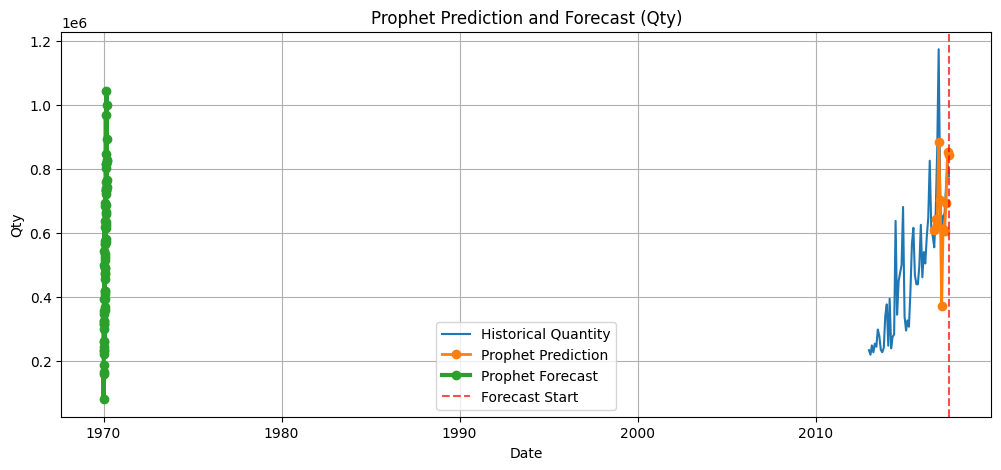

In [134]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_qty.index,
    monthly_qty.values,
    label='Historical Quantity')

plt.plot(
    prophet_pred_qty.index,
    prophet_pred_qty.values,
    marker='o',
    linewidth=2,
    label='Prophet Prediction')

plt.plot(
    prophet_future_qty.index,
    prophet_future_qty['yhat'],
    marker='o',
    linewidth=3,
    label='Prophet Forecast')

plt.axvline(
    monthly_qty.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start')

plt.title('Prophet Prediction and Forecast (Qty)')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

In [133]:
forecast_qty = prophet_final_qty.predict(future_qty)

forecast_table = forecast_qty[['ds', 'yhat']].tail(12)

forecast_table.columns = ['Date', 'Forecast_Qty']

forecast_table['Forecast_Qty'] = (
    forecast_table['Forecast_Qty']
    .round(0)
    .astype(int)
)

forecast_table

,Date,Forecast_Qty
55,2017-08-01,735655
56,2017-09-01,721037
57,2017-10-01,759902
58,2017-11-01,846274
59,2017-12-01,1043713
60,2018-01-01,801671
61,2018-02-01,745035
62,2018-03-01,827046
63,2018-04-01,764517
64,2018-05-01,825005


## Revenue Monthly

In [91]:
prophet_train_revenue = train_revenue.reset_index()
prophet_train_revenue.columns = ['ds', 'y']
prophet_model_revenue = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_model_revenue.fit(prophet_train_revenue)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [92]:
future_test_revenue = prophet_model_revenue.make_future_dataframe(periods=len(test_revenue), freq='MS')
forecast_test_revenue = prophet_model_revenue.predict(future_test_revenue)
prophet_pred_revenue = forecast_test_revenue[['ds', 'yhat']].tail(len(test_revenue))
prophet_pred_revenue = pd.Series(prophet_pred_revenue['yhat'].values, index=test_revenue.index)

In [93]:
prophet_full_revenue = monthly_revenue.reset_index()
prophet_full_revenue.columns = ['ds', 'y']
prophet_final_revenue = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_final_revenue.fit(prophet_full_revenue)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [94]:
future_revenue = prophet_final_revenue.make_future_dataframe(periods=12, freq='MS')
forecast_revenue = prophet_final_revenue.predict(future_revenue)
prophet_future_revenue = forecast_revenue[['ds', 'yhat']].tail(12).set_index('ds')

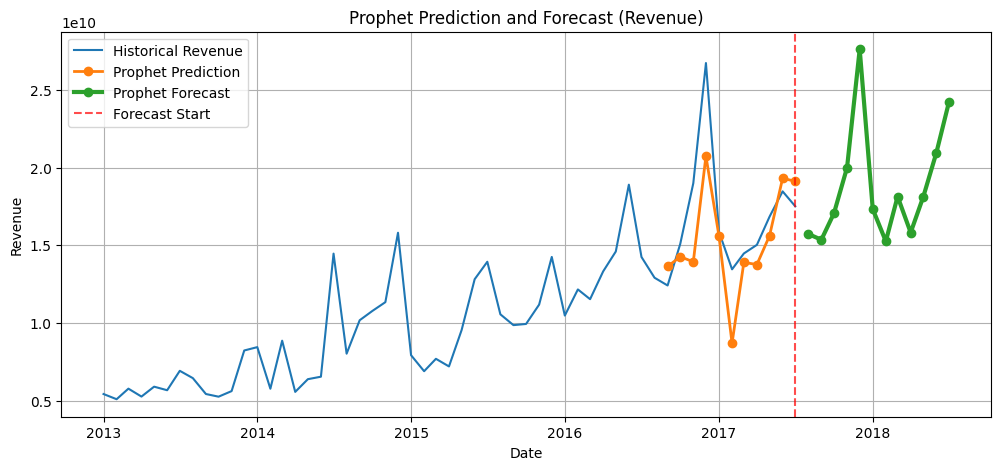

In [135]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')

plt.plot(
    prophet_pred_revenue.index,
    prophet_pred_revenue.values,
    marker='o',
    linewidth=2,
    label='Prophet Prediction')

plt.plot(
    prophet_future_revenue.index,
    prophet_future_revenue['yhat'],
    marker='o',
    linewidth=3,
    label='Prophet Forecast')

plt.axvline(
    monthly_revenue.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start')

plt.title('Prophet Prediction and Forecast (Revenue)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

# Evaluasi

In [96]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, mape
results = []

results.append(
    ["ARMA", *evaluate(test_qty, arima_pred_qty)]
)

results.append(
    ["SARIMA", *evaluate(test_qty, sarima_pred_qty)]
)

results.append(
    ["Holt Winter", *evaluate(test_qty, hw_pred_qty)]
)

results.append(
    ["Prophet", *evaluate(test_qty, prophet_pred_qty)]
)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results

,Model,MAE,RMSE,MAPE
0,ARMA,137517.235587,199374.883597,15.993035
1,SARIMA,122174.097510,191312.975965,14.007074
2,Holt Winter,118387.999367,155782.177061,14.366167
3,Prophet,98015.315301,136006.555943,12.520985


In [97]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, mape
results = []

results.append(
    ["ARMA", *evaluate(test_revenue, arima_pred_revenue)]
)

results.append(
    ["SARIMA", *evaluate(test_revenue, sarima_pred_revenue)]
)

results.append(
    ["Holt Winter", *evaluate(test_revenue, hw_pred_revenue)]
)

results.append(
    ["Prophet", *evaluate(test_revenue, prophet_pred_revenue)]
)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results

,Model,MAE,RMSE,MAPE
0,ARMA,3.089416e+09,4.534324e+09,15.899842
1,SARIMA,2.734863e+09,4.361800e+09,13.819485
2,Holt Winter,1.875137e+09,2.777932e+09,10.254863
3,Prophet,2.149669e+09,2.907658e+09,12.262954


# Grafik

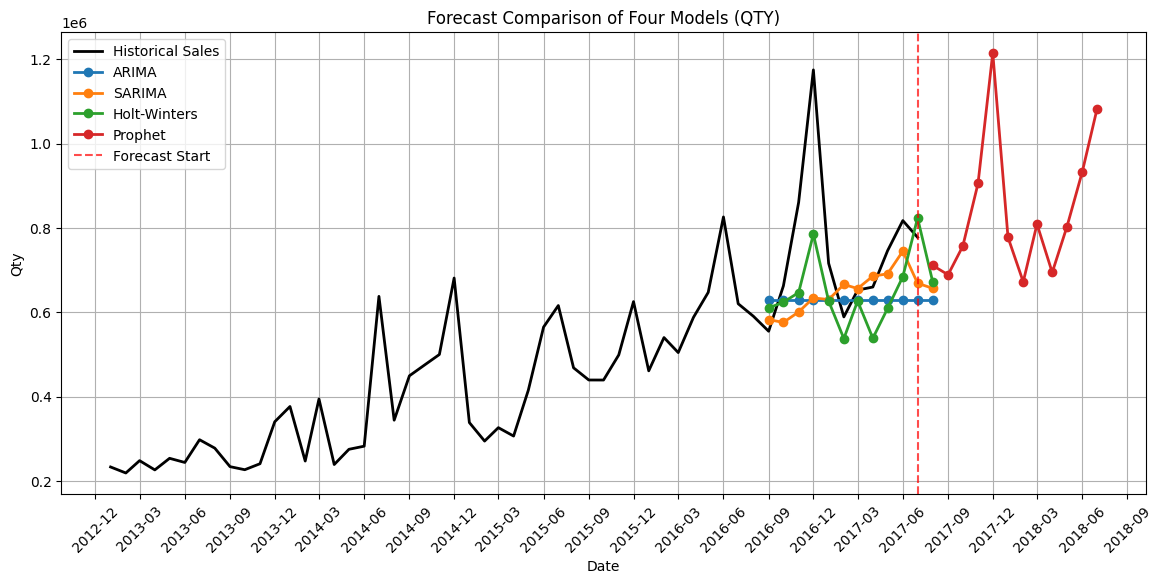

In [98]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_qty.index,
    monthly_qty.values,
    color='black',
    linewidth=2,
    label='Historical Sales'
)

# ARIMA
plt.plot(
    arima_future_qty.index,
    arima_future_qty.values,
    marker='o',
    linewidth=2,
    label='ARIMA'
)

# SARIMA
plt.plot(
    sarima_future_qty.index,
    sarima_future_qty.values,
    marker='o',
    linewidth=2,
    label='SARIMA'
)

# Holt-Winters
plt.plot(
    hw_future_qty.index,
    hw_future_qty.values,
    marker='o',
    linewidth=2,
    label='Holt-Winters'
)

# Prophet
plt.plot(
    prophet_future_qty.index,
    prophet_future_qty['yhat'],
    marker='o',
    linewidth=2,
    label='Prophet'
)

plt.axvline(
    monthly_qty.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start'
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.title('Forecast Comparison of Four Models (QTY)')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)

plt.show()

In [99]:
prop_tabel = pd.DataFrame({
    'Date': prophet_future_qty.index.strftime('%b-%Y'),
    'Forecast_Qty': prophet_future_qty['yhat'].values/1_000_000
})

prop_tabel

,Date,Forecast_Qty
0,Aug-2017,0.710988
1,Sep-2017,0.688853
2,Oct-2017,0.756664
3,Nov-2017,0.905484
4,Dec-2017,1.215052
5,Jan-2018,0.777703
6,Feb-2018,0.672120
7,Mar-2018,0.809166
8,Apr-2018,0.694374
9,May-2018,0.803239


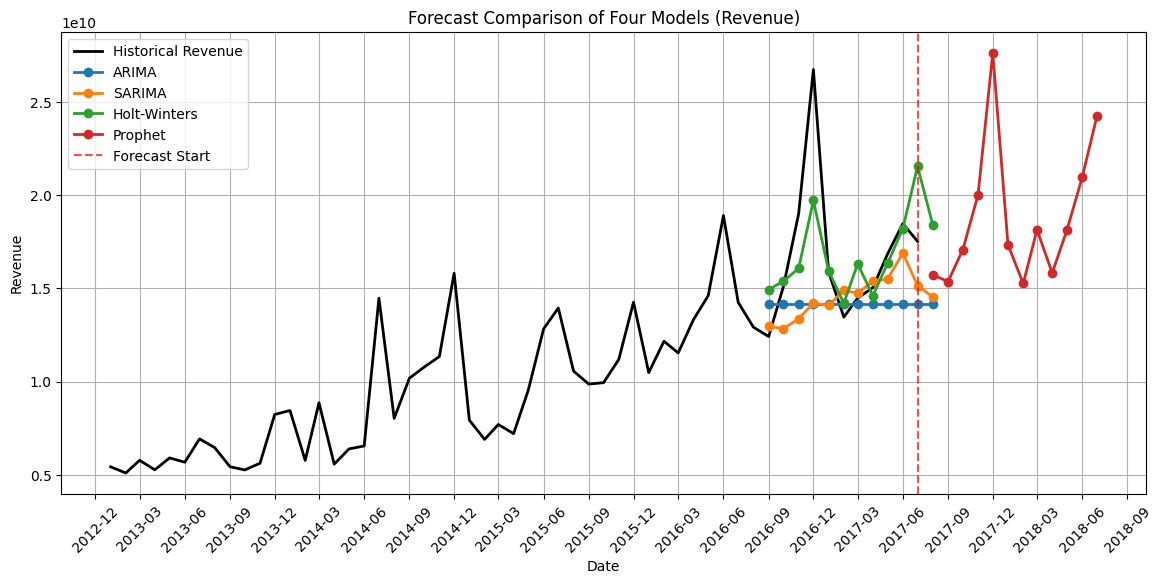

In [100]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color='black',
    linewidth=2,
    label='Historical Revenue'
)

# ARIMA
plt.plot(
    arima_future_revenue.index,
    arima_future_revenue.values,
    marker='o',
    linewidth=2,
    label='ARIMA'
)

# SARIMA
plt.plot(
    sarima_future_revenue.index,
    sarima_future_revenue.values,
    marker='o',
    linewidth=2,
    label='SARIMA'
)

# Holt-Winters
plt.plot(
    hw_future_revenue.index,
    hw_future_revenue.values,
    marker='o',
    linewidth=2,
    label='Holt-Winters'
)

# Prophet
plt.plot(
    prophet_future_revenue.index,
    prophet_future_revenue['yhat'],
    marker='o',
    linewidth=2,
    label='Prophet'
)

plt.axvline(
    monthly_revenue.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start'
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.title('Forecast Comparison of Four Models (Revenue)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)

plt.show()

In [101]:
hw_tabel = pd.DataFrame({
    'Date': hw_future_revenue.index.strftime('%b-%Y'),
    'Forecast_Revenue': hw_future_revenue.values/ 1_000_000_000
})
hw_tabel['Forecast_Revenue'] = hw_tabel['Forecast_Revenue'].round(2)
hw_tabel

,Date,Forecast_Revenue
0,Sep-2016,14.93
1,Oct-2016,15.38
2,Nov-2016,16.06
3,Dec-2016,19.71
4,Jan-2017,15.93
5,Feb-2017,14.19
6,Mar-2017,16.32
7,Apr-2017,14.60
8,May-2017,16.34
9,Jun-2017,18.20


# Data Forecast Final

In [102]:
qty_full = monthly_qty.reset_index()
qty_full.columns = ['ds','y']

prophet_final_qty = Prophet()

prophet_final_qty.fit(
    qty_full
)

future_qty = prophet_final_qty.make_future_dataframe(
    periods=12,
    freq='MS'
)

prophet_future_qty = prophet_final_qty.predict(
    future_qty
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [103]:
hw_final_revenue = ExponentialSmoothing(
    monthly_revenue,
    trend='mul',
    seasonal='add',
    seasonal_periods=12
)

hw_final_fit_revenue = hw_final_revenue.fit()

hw_final_future_revenue = hw_final_fit_revenue.forecast(12)

In [104]:
future_dates = pd.date_range(
    start=monthly_revenue.index[-1]
          + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

hw_final_future_revenue.index = future_dates

In [110]:
forecast_final = pd.DataFrame({
    'Date': prophet_future_qty['ds'].tail(12).values,

    'Forecast_Qty': prophet_future_qty['yhat']
                    .tail(12)
                    .round(0)
                    .values,

    'Forecast_Revenue': hw_final_future_revenue
                        .round(0)
                        .values
})

forecast_final['Forecast_Revenue'] = forecast_final['Forecast_Revenue'].apply(
    lambda x: f"{x:,.0f}"
)

forecast_final

,Date,Forecast_Qty,Forecast_Revenue
0,2017-08-01,735655.0,"18,318,378,748"
1,2017-09-01,721037.0,"18,683,410,029"
2,2017-10-01,759902.0,"19,080,496,931"
3,2017-11-01,846274.0,"19,990,809,652"
4,2017-12-01,1043713.0,"23,535,180,360"
5,2018-01-01,801671.0,"19,851,469,129"
6,2018-02-01,745035.0,"19,424,657,222"
7,2018-03-01,827046.0,"20,778,223,049"
8,2018-04-01,764517.0,"20,352,295,226"
9,2018-05-01,825005.0,"21,985,019,817"


In [106]:
forecast_final.to_csv(
    'forecast_final.csv',
    index=False
)